In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pyplot import title

from ML4QS.Python3Code.Chapter3.OutlierDetection import *
from ML4QS.Python3Code.Chapter3.DataTransformation import *

In [225]:
df.columns

Index(['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'acc_lin_x', 'acc_lin_y', 'acc_lin_z', 'yaw', 'pitch', 'roll',
       'subject', 'exercise', 'set_nr', 'focus', 'hr'],
      dtype='object')

In [217]:
df = pd.read_csv("data/merged_df.csv")
# df = df.rename(columns={
#     "acc_x": "acc_lin_x",
#     "acc_y": "acc_lin_y",
#     "acc_z": "acc_lin_z",
# }).rename(columns={
#     "Acceleration x (m/s^2)": "acc_x",
#     "Acceleration y (m/s^2)": "acc_y",
#     "Acceleration z (m/s^2)": "acc_z",
# })
# df.columns

Index(['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'acc_lin_x', 'acc_lin_y', 'acc_lin_z', 'yaw', 'pitch', 'roll',
       'subject', 'exercise', 'set_nr', 'focus', 'hr'],
      dtype='object')

In [220]:
df_test = df[
    (df["set_nr"] == 1) & (df["exercise"] == 0) & (df["subject"] == 0)
][["time", "acc_lin_x", "acc_lin_y", "acc_lin_z"]]
df_test

,time,acc_lin_x,acc_lin_y,acc_lin_z
0,0.00,-1.268512,0.422935,-1.102830
1,0.02,0.402870,0.328072,-1.159232
2,0.04,0.969000,1.239809,-1.068749
3,0.06,-0.650567,1.916238,-0.745118
4,0.08,-0.752843,0.836309,0.770113
...,...,...,...,...
1495,29.90,-0.919756,-0.387994,0.058132
1496,29.92,-0.005227,-0.456264,0.306620
1497,29.94,0.277655,-0.296665,0.270867
1498,29.96,0.104579,-0.385082,0.109476


In [59]:
# fig = plt.figure(figsize=(15,10))
# plt.plot(df_test["acc_x_lin"], label="acc_x_lin")

In [13]:
chauvenet = DistributionBasedOutlierDetection().chauvenet
mixture_model = DistributionBasedOutlierDetection().mixture_model
simple_distance_based = DistanceBasedOutlierDetection().simple_distance_based
local_outlier_factor = DistanceBasedOutlierDetection().local_outlier_factor


In [222]:
df_test.columns

Index(['time', 'acc_lin_x', 'acc_lin_y', 'acc_lin_z'], dtype='object')

In [223]:
df_chau = chauvenet(data_table=df_test, col="acc_lin_x", C=2)
df_chau = chauvenet(data_table=df_chau, col="acc_lin_y", C=2)
df_chau = chauvenet(data_table=df_chau, col="acc_lin_z", C=2)
df_chau["chau_outlier_xyz"] = df_chau["acc_lin_x_outlier"] | df_chau["acc_lin_y_outlier"] | df_chau["acc_lin_z_outlier"]
df_chau.head()

,time,acc_lin_x,acc_lin_y,acc_lin_z,acc_lin_x_outlier,acc_lin_y_outlier,acc_lin_z_outlier,chau_outlier_xyz
0,0.00,-1.268512,0.422935,-1.102830,False,False,False,False
1,0.02,0.402870,0.328072,-1.159232,False,False,False,False
2,0.04,0.969000,1.239809,-1.068749,False,False,False,False
3,0.06,-0.650567,1.916238,-0.745118,False,False,False,False
4,0.08,-0.752843,0.836309,0.770113,False,False,False,False


In [224]:
df_chau["chau_outlier_xyz"].sum()

12

In [120]:
# looking into the local_outlier_factor function, z score normalizing for axes is done inside
df_local_outlier_factor= local_outlier_factor(
    data_table=df_test, cols=['acc_lin_x', 'acc_lin_y', 'acc_lin_z'], k=10, d_function="euclidean"
)
df_chau.columns
df_local_outlier_factor.columns


Calculating local outlier factor.
Completed 0 steps for LOF.
Completed 100 steps for LOF.
Completed 200 steps for LOF.
Completed 300 steps for LOF.
Completed 400 steps for LOF.
Completed 500 steps for LOF.
Completed 600 steps for LOF.
Completed 700 steps for LOF.
Completed 800 steps for LOF.
Completed 900 steps for LOF.
Completed 1000 steps for LOF.
Completed 1100 steps for LOF.
Completed 1200 steps for LOF.
Completed 1300 steps for LOF.
Completed 1400 steps for LOF.


Index(['time', 'acc_lin_x', 'acc_lin_y', 'acc_lin_z', 'acc_lin_x_outlier',
       'acc_lin_y_outlier', 'acc_lin_z_outlier', 'chau_outlier_xyz', 'lof'],
      dtype='object')

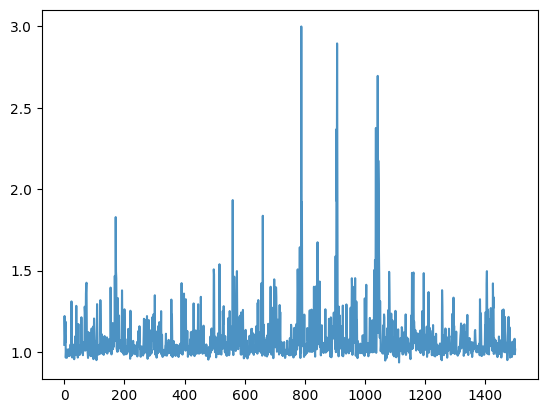

In [121]:
df_local_outlier_factor["lof"].min()

plt.plot(df_local_outlier_factor.index, df_local_outlier_factor["lof"], alpha=0.8)

In [122]:
df_local_outlier_factor["lof_outlier_xyz"] = df_local_outlier_factor["lof"] > 2
df_local_outlier_factor.head()

,time,acc_lin_x,acc_lin_y,acc_lin_z,acc_lin_x_outlier,acc_lin_y_outlier,acc_lin_z_outlier,chau_outlier_xyz,lof,lof_outlier_xyz
0,0.00,-1.268512,0.422935,-1.102830,False,False,False,False,1.043673,False
1,0.02,0.402870,0.328072,-1.159232,False,False,False,False,1.220572,False
2,0.04,0.969000,1.239809,-1.068749,False,False,False,False,1.137358,False
3,0.06,-0.650567,1.916238,-0.745118,False,False,False,False,1.054935,False
4,0.08,-0.752843,0.836309,0.770113,False,False,False,False,1.186609,False


In [123]:
def plot_outliers(df, name, col):
    plt.style.use("default")
    plt.figure(figsize=(12, 6), facecolor="white")

    mask = df[f"{col}_outlier"]

    plt.plot(df.index, df[f"{col}"], alpha=0.8)
    plt.scatter(
        df.index[mask],
        df.loc[mask, f"{col}"],
        s=30,
        label="Outliers",
        marker="x",
        color="red",
        linewidths=2,
        # zorder=10,
    )
    plt.xlim(-10, df.index.max() + 10)

    plt.xticks(
        np.arange(0, df.index.max() + 2, 100)
    )
    plt.title(f"{name} Outlier Detection")



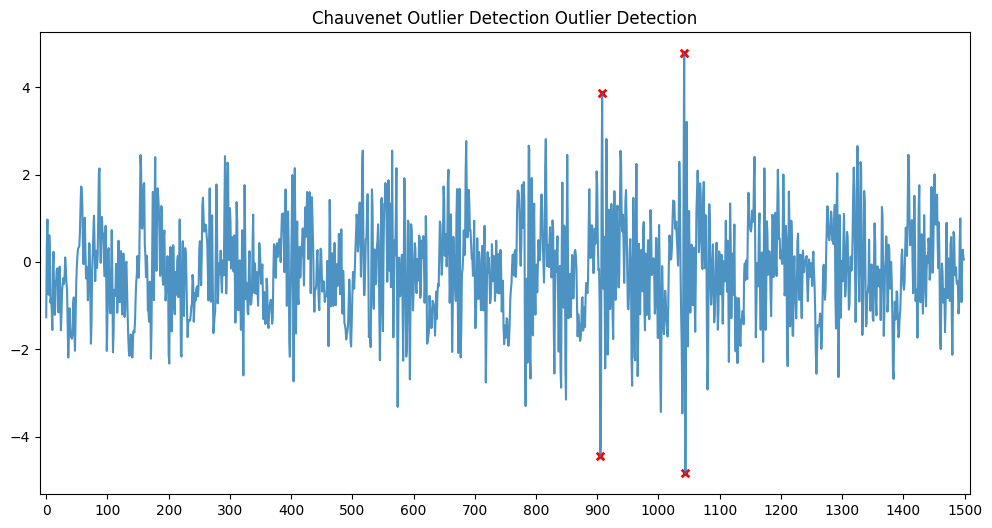

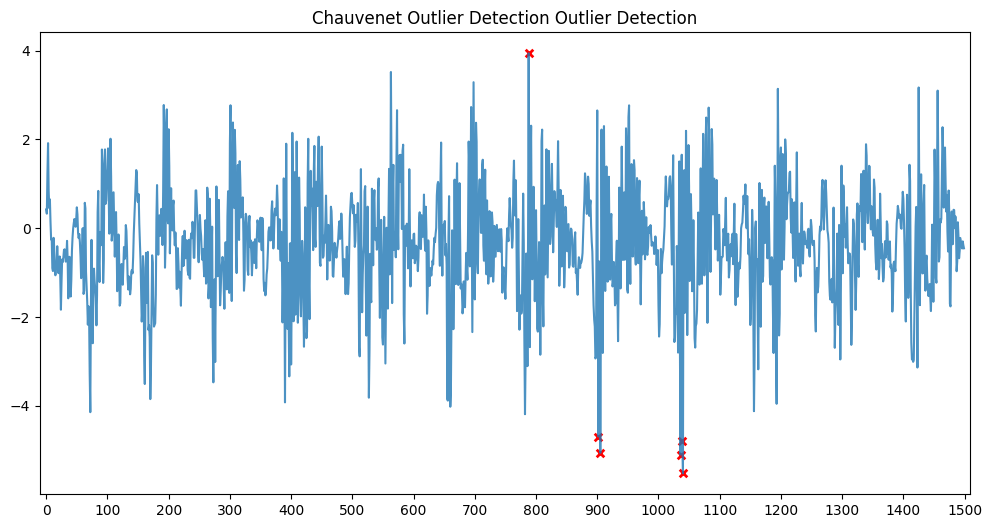

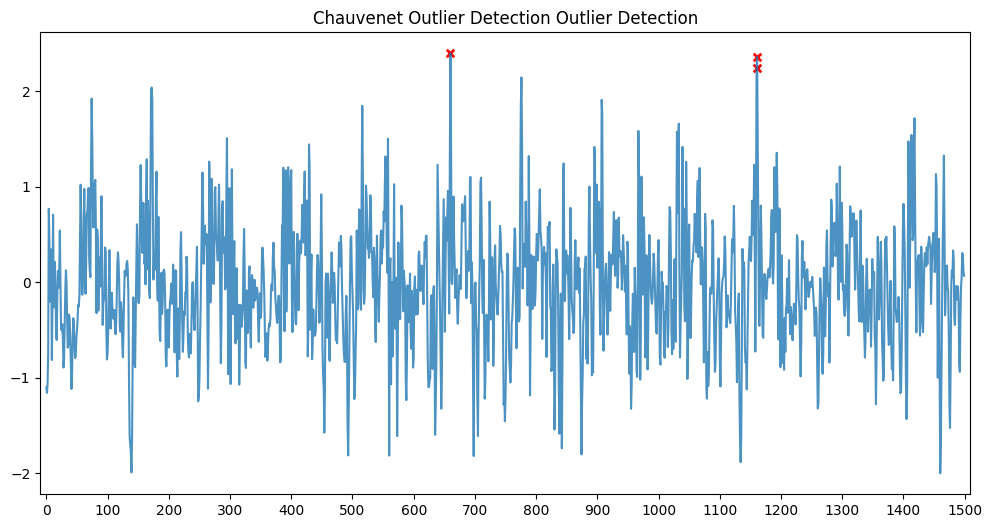

In [124]:
plot_outliers(df_chau, "Chauvenet Outlier Detection", "acc_lin_x")
plot_outliers(df_chau, "Chauvenet Outlier Detection", "acc_lin_y")
plot_outliers(df_chau, "Chauvenet Outlier Detection", "acc_lin_z")

In [82]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_outliers(df, name, mask_col, cols=("acc_lin_x", "acc_lin_y", "acc_lin_z")):
    x_col, y_col, z_col = cols

    mask = df[mask_col].astype(bool)
    t = np.arange(len(df))

    fig = plt.figure(figsize=(10, 8), facecolor="white")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("white")

    normal = ax.scatter(
        df.loc[~mask, x_col],
        df.loc[~mask, y_col],
        df.loc[~mask, z_col],
        c=t[~mask],
        cmap="viridis",
        s=10,
        alpha=0.45,
        label="Normal"
    )

    ax.scatter(
        df.loc[mask, x_col],
        df.loc[mask, y_col],
        df.loc[mask, z_col],
        marker="x",
        color="red",
        s=80,
        linewidths=2,
        label="Outliers",
        zorder=10
    )

    cbar = fig.colorbar(normal, ax=ax, pad=0.1)
    cbar.set_label("Time / sample index")

    ax.set_title(f"{name}: 3D XYZ Outlier Detection")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"plots/{mask_col}_plot_3d")


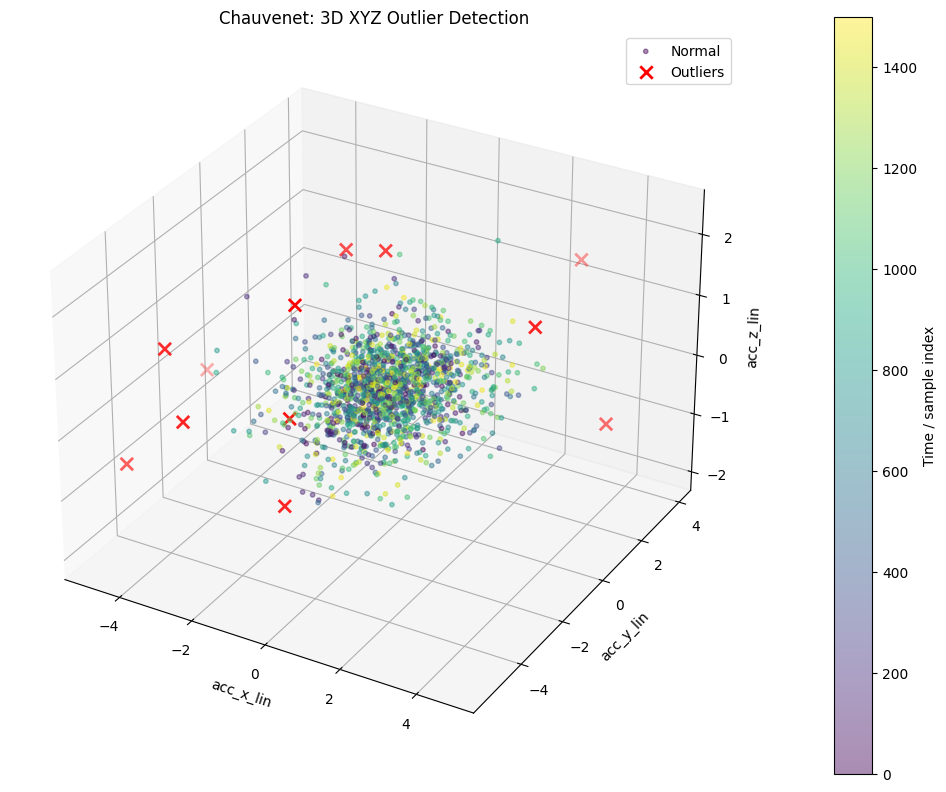

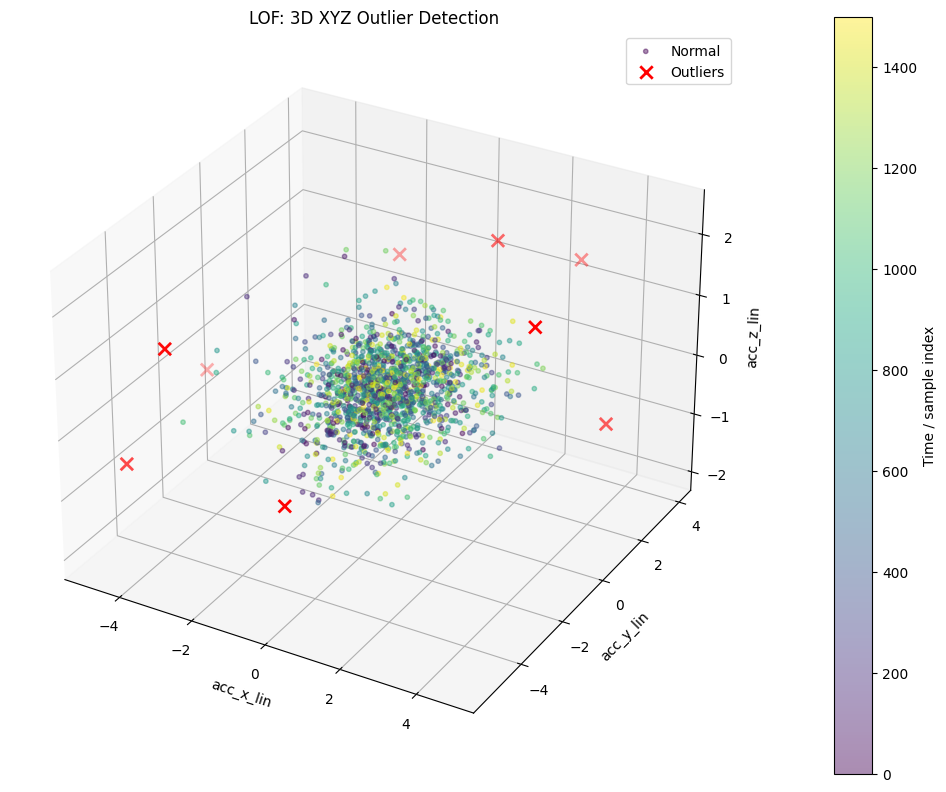

In [83]:
plot_3d_outliers(
    df_chau,
    "Chauvenet",
    "chau_outlier_xyz"
)

plot_3d_outliers(
    df_local_outlier_factor,
    "LOF",
    "lof_outlier_xyz"
)

In [84]:
def plot_xyz_outliers_over_time(df, name, mask_col):
    cols = ["acc_lin_x", "acc_lin_y", "acc_lin_z"]
    mask = df[mask_col].astype(bool)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, facecolor="white")

    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col], alpha=0.8)
        ax.scatter(
            df.index[mask],
            df.loc[mask, col],
            marker="x",
            color="red",
            s=70,
            linewidths=2,
            label="Outliers"
        )
        ax.set_ylabel(col)
        ax.grid(alpha=0.25)

    axes[0].set_title(f"{name}: XYZ Outliers Over Time")
    axes[-1].set_xlabel("Time / sample")
    axes[0].legend()

    plt.tight_layout()
    plt.savefig(f"plots/{mask_col}_plot_ts")

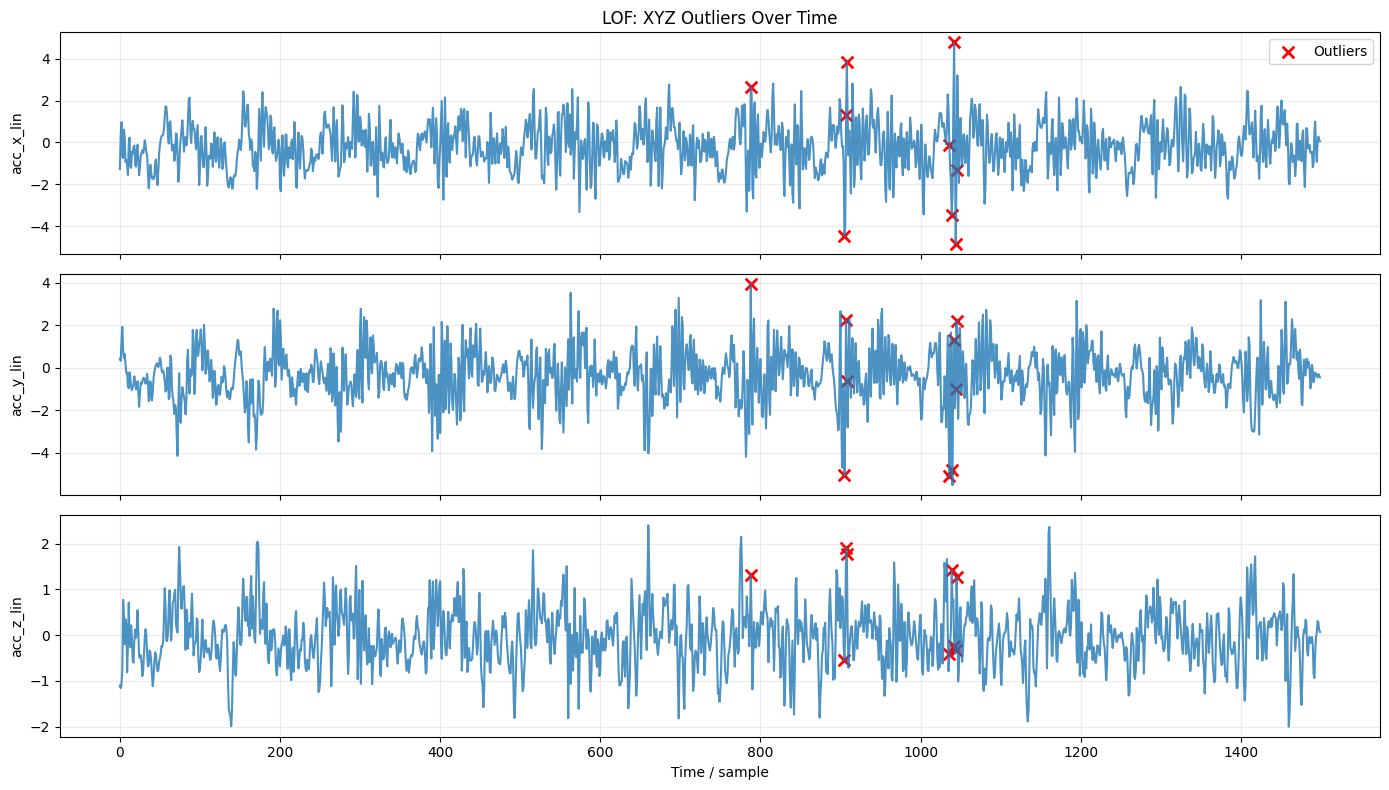

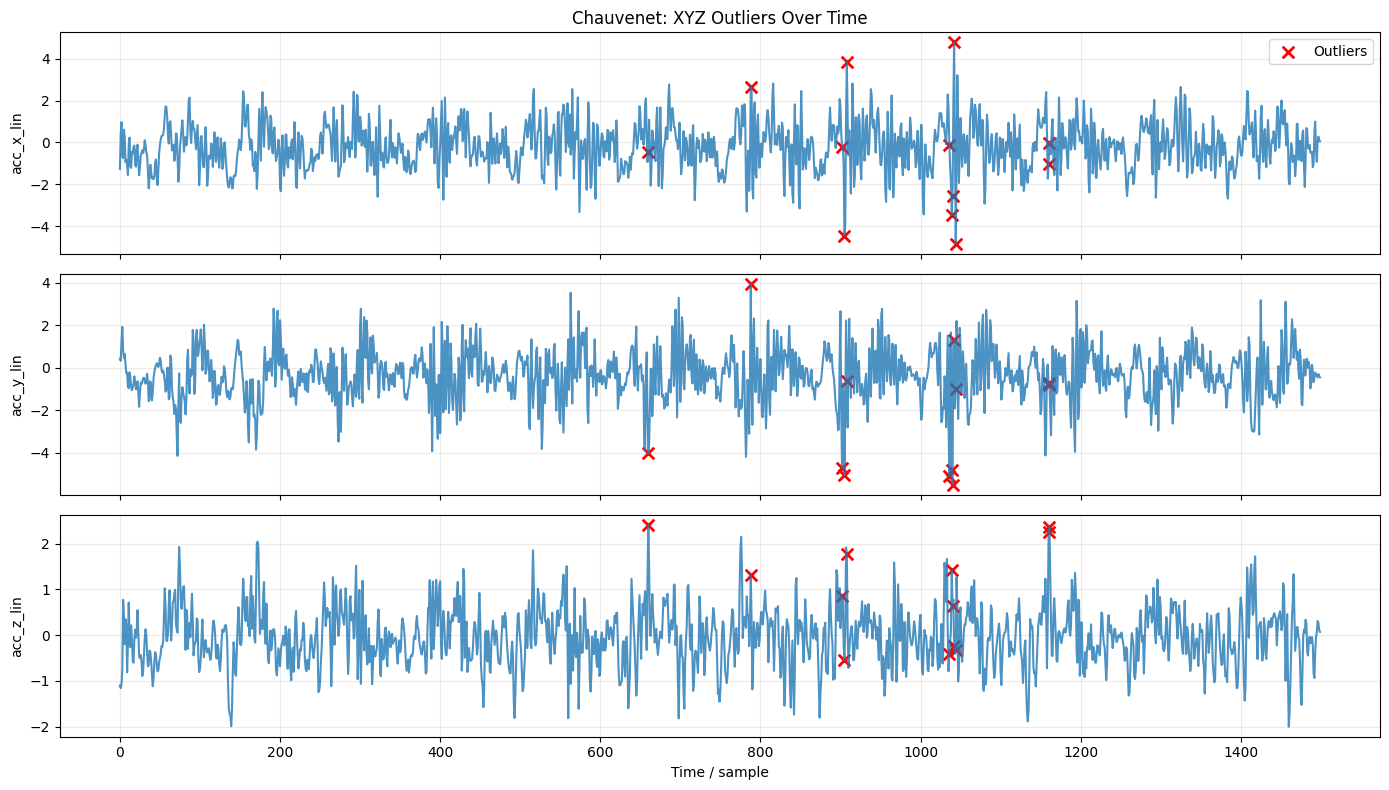

In [85]:
plot_xyz_outliers_over_time(df_local_outlier_factor, "LOF", "lof_outlier_xyz")
plot_xyz_outliers_over_time(df_chau, "Chauvenet", "chau_outlier_xyz")

In [174]:
# df_org = df.copy()
df = df_org.copy()

In [208]:
def detect_outliers(df):
    """
    Takes about 27 minutes to run on 36k dataset, so quite slow
    looking at 3d plots compared with Chavenet, seems to detect overall outliers slightly better
    That makes sense because takes into account all 3 dimensions at once.
    """

    lof_detector = DistanceBasedOutlierDetection()

    group_cols = ["subject", "set_nr", "exercise", "focus"]
    sensors = ["acc_lin", "acc", "gyro", "orientation"]

    sensor_cols = {
        sensor: (["yaw", "pitch", "roll"] if sensor == "orientation" else [f"{sensor}_x", f"{sensor}_y", f"{sensor}_z"])
        for sensor in sensors
    }
    df["_row_id"] = np.arange(len(df))

    df = df[(df["_row_id"] % 100 == 0)]
    #
    i = 0
    all_groups = []
    for _, df_group in df.groupby(group_cols, sort=False):
        for sensor, cols in sensor_cols.items():
            print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
            print(f"progress: {i / 0.96:.2f} %") # 24 * 4 sensors
            print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
            df_group = lof_detector.local_outlier_factor(
                df_group,
                cols,
                d_function="euclidean",
                k=10
            )
            # if i % 100 == 0:

            df_group = df_group.rename(columns={"lof": f"{sensor}_lof"})
            df_group[f"{sensor}_lof_outlier"] = df_group[f"{sensor}_lof"] > 2

            i += 1
        df_group = df_group[["_row_id"] + [f"{sensor}_lof_outlier" for sensor in sensors] + [f"{sensor}_lof" for sensor in sensors]]
        all_groups.append(df_group)

    full_lof_df = pd.concat(all_groups)

    df = df.merge(full_lof_df, on="_row_id", how="left")
    df = df.drop(columns="_row_id")

    for col in df.columns:
        if col.endswith("lof_outlier"):
            print(f"found {df[col].sum()} outliers for {col[:-len('lof_outlier') -1]} out of {len(df)} values ({df[col].sum() / len(df) * 100:.2f} %)")
    return df
df = detect_outliers(df)

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 0.00 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 1.04 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 2.08 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 3.12 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 4.17 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 5.21 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier factor.
Completed 0 steps for LOF.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
progress: 6.25 %
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Calculating local outlier

In [176]:
df.to_csv("df_outliers_lof.csv", index=False)

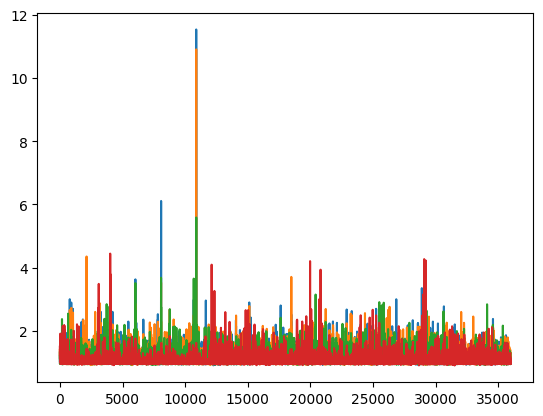

In [178]:
for col in df.columns:
    if col.endswith("_lof"):
        plt.plot(df[col], label=col)

In [188]:
def interpolate_outliers(df):
    sensors = ["acc_lin", "acc", "gyro", "orientation"]
    for sensor in sensors:
        if sensor == "orientation":
            cols = ["yaw", "pitch", "roll"]
        else:
            cols = [f"{sensor}_x", f"{sensor}_y", f"{sensor}_z"]
        df[cols] = df[cols].mask(df[f"{sensor}_lof_outlier"], np.nan)
        for col in cols:
            df[col] = df[col].interpolate()
    return df
df = interpolate_outliers(df)

In [187]:
df.head()

,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_lin_x,acc_lin_y,acc_lin_z,...,hr,acc_lin_lof,acc_lin_lof_outlier,acc_lof,acc_lof_outlier,gyro_lof,gyro_lof_outlier,orientation_lof,orientation_lof_outlier,_row_id
0,0.00,-7.961519,6.186045,1.289133,0.830240,-0.729040,-1.797499,-1.268512,0.422935,-1.102830,...,102.00,1.043673,False,1.159544,False,1.129106,False,1.499490,False,0
1,0.02,-8.397555,6.498572,1.462883,0.873349,-0.642368,-1.771620,0.402870,0.328072,-1.159232,...,102.02,1.220572,False,1.080336,False,1.039125,False,1.291029,False,1
2,0.04,-6.916147,6.205850,1.390827,0.955115,-0.523623,-1.789137,0.969000,1.239809,-1.068749,...,102.04,1.137358,False,1.234716,False,1.194678,False,1.288453,False,2
3,0.06,-6.552774,6.904986,1.445559,0.959972,-0.367234,-1.795568,-0.650567,1.916238,-0.745118,...,102.06,1.054935,False,1.426371,False,1.343967,False,1.214718,False,3
4,0.08,-8.338168,7.342867,1.731426,0.840283,-0.452271,-1.806790,-0.752843,0.836309,0.770113,...,102.08,1.186609,False,1.291522,False,1.059990,False,1.239843,False,4


In [191]:
def low_pass_smoothing(df, cutoff_frequency=5):
    """
    lpf should also be passed in parts because otherwise it would smooth boundaries. This goes quick though
    """
    lpf = LowPassFilter().low_pass_filter

    group_cols = ["subject", "set_nr", "exercise", "focus"]
    sensors = ["acc_lin", "acc", "gyro", "orientation"]

    sensor_cols = {
        sensor: (["yaw", "pitch", "roll"] if sensor == "orientation" else [f"{sensor}_x", f"{sensor}_y", f"{sensor}_z"])
        for sensor in sensors
    }
    df["_row_id"] = np.arange(len(df))
    i = 0
    all_groups = []
    for _, df_group in df.groupby(group_cols):
        for sensor, cols in sensor_cols.items():
            if sensor == "orientation":
                sensor_coord_cols = ["yaw", "pitch", "roll"]
            else:
                sensor_coord_cols = [f"{sensor}_x", f"{sensor}_y", f"{sensor}_z"]

            for col in sensor_coord_cols:
                df_group = lpf(data_table=df_group, col=col, sampling_frequency=50, cutoff_frequency=cutoff_frequency)

        lowpass_cols = [f"{col}_lowpass" for cols in sensor_cols.values() for col in cols]
        df_group = df_group[["_row_id"] + lowpass_cols]
        all_groups.append(df_group)

    full_lpf_df = pd.concat(all_groups)

    df = df.merge(full_lpf_df, on="_row_id", how="left")
    df = df.drop(columns="_row_id")

    return df

df = low_pass_smoothing(df)

In [194]:
df.to_csv("data/df_processed.csv", index=False)